<a href="https://colab.research.google.com/github/DJReazy/undergrad_ml_assignments/blob/main/HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1

1.1)
It keeps the model from using very large coefficients, which helps prevent overfitting and makes the model simpler.


1.2)
Regularization controls complexity. More penalty = simpler model (higher bias, lower variance). Less penalty = more flexible model (lower bias, higher variance).


1.3)
Ridge shrinks coefficients but keeps all of them.
LASSO can shrink some coefficients to zero, removing features.
Ridge keeps everything, LASSO does feature selection.


1.4)
We standardize variables (mean 0, std 1) so all features are on the same scale. This prevents some variables from being unfairly penalized more than others.


1.5)
We choose α using cross-validation by picking the value that gives the best performance.


1.6)
No. We only use prediction error (MSE) because we care about how well the model predicts new data, not the penalty.

# Q2

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/data/cars_hw.csv")

# Check columns
print(df.columns)
df.head()

Index(['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run',
       'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission',
       'Transmission_Type', 'Price'],
      dtype='object')


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [4]:
df["Age"] = 2024 - df["Make_Year"]   # adjust year if needed

In [5]:
X = df[["Mileage_Run", "Age"]]
y = df["Price"]   # or whatever your target is

In [6]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])
print(feature_names)

['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [8]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_scaled, y)

coeffs = pd.Series(linreg.coef_, index=feature_names)
print(coeffs)

Mileage_Run          6.686165e+05
Age                 -1.841941e+05
Mileage_Run^2       -1.494679e+05
Mileage_Run Age     -1.251592e+06
Age^2                2.156399e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    2.833392e+05
Mileage_Run Age^2    5.280829e+05
Age^3               -1.389370e+05
dtype: float64


2.2) The interaction between Mileage_Run and Age is negative.

In [9]:
from sklearn.linear_model import LassoCV

alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20)
lasso.fit(X_scaled, y)

print("Best alpha:", lasso.alpha_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 13229914430.28125, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 131934043992.82812, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 298840628722.28125, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Obje

Best alpha: 233.57214690901213


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 34655310357.578125, tolerance: 12733875574.325783
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 234997981031.34375, tolerance: 12733875574.325783
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 189534678437.23438, tolerance: 12733875574.325783
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Converge

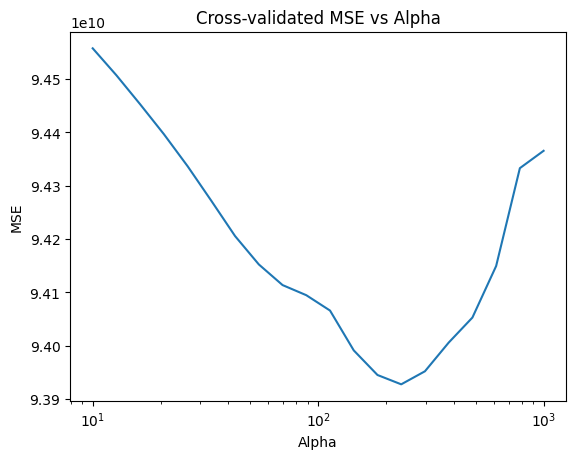

In [10]:
import matplotlib.pyplot as plt

mean_mse = np.mean(lasso.mse_path_, axis=1)

plt.plot(lasso.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.title("Cross-validated MSE vs Alpha")
plt.show()

2.3) We used LassoCV with 20-fold cross-validation to choose the best α. The optimal α is the one that minimizes the cross-validated MSE (around where the curve is lowest, roughly in the mid-range of the tested values).

2.4) The MSE decreases as α increases at first, reaches a minimum, and then increases again. This shows that a moderate amount of regularization gives the best performance.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.152e+13, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.094e+13, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.019e+13, tolerance: 1.316e

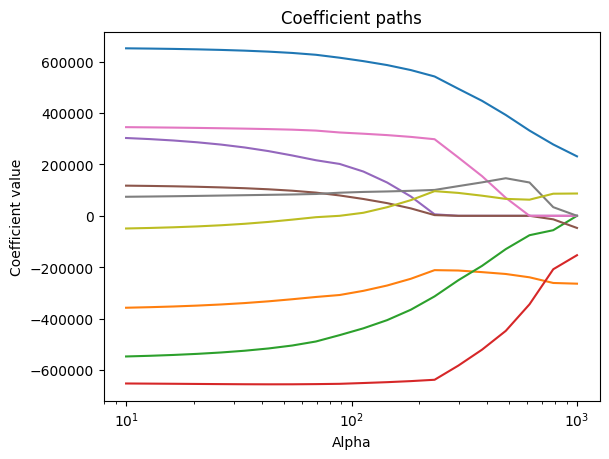

In [11]:
from sklearn.linear_model import Lasso

coefs = []

for a in alphas:
    model = Lasso(alpha=a)
    model.fit(X_scaled, y)
    coefs.append(model.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient value")
plt.title("Coefficient paths")
plt.show()

2.5) As α increases, the coefficients shrink toward zero. Some coefficients decrease steadily, while others approach zero more quickly. This shows how LASSO simplifies the model as regularization increases.

In [12]:
lasso_coeffs = pd.Series(lasso.coef_, index=feature_names)

print(lasso_coeffs)
print("\nNon-zero features:")
print(lasso_coeffs[lasso_coeffs != 0])

zero_prop = np.mean(lasso_coeffs == 0)
print("\nProportion zero:", zero_prop)

Mileage_Run          541816.554848
Age                 -211301.604371
Mileage_Run^2       -313330.303312
Mileage_Run Age     -637593.936568
Age^2                  5841.326277
Mileage_Run^3          2735.702468
Mileage_Run^2 Age    297787.051885
Mileage_Run Age^2    100600.242401
Age^3                 95884.589970
dtype: float64

Non-zero features:
Mileage_Run          541816.554848
Age                 -211301.604371
Mileage_Run^2       -313330.303312
Mileage_Run Age     -637593.936568
Age^2                  5841.326277
Mileage_Run^3          2735.702468
Mileage_Run^2 Age    297787.051885
Mileage_Run Age^2    100600.242401
Age^3                 95884.589970
dtype: float64

Proportion zero: 0.0


2.6) All features are selected because none of the coefficients are equal to zero.
The proportion of coefficients set to zero is 0.0.

In [13]:
comparison = pd.DataFrame({
    "Linear": linreg.coef_,
    "LASSO": lasso.coef_
}, index=feature_names)

print(comparison)

                         Linear          LASSO
Mileage_Run        6.686165e+05  541816.554848
Age               -1.841941e+05 -211301.604371
Mileage_Run^2     -1.494679e+05 -313330.303312
Mileage_Run Age   -1.251592e+06 -637593.936568
Age^2              2.156399e+05    5841.326277
Mileage_Run^3     -6.514490e+04    2735.702468
Mileage_Run^2 Age  2.833392e+05  297787.051885
Mileage_Run Age^2  5.280829e+05  100600.242401
Age^3             -1.389370e+05   95884.589970


2.7)
Compared to linear regression:

Most coefficients decrease in magnitude under LASSO.
No coefficients increase significantly.
Some coefficients change slightly, but the signs mostly stay the same.

# Q3

In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/data/heart_failure_clinical_records_dataset.csv")

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [16]:
X_cont = df[["age", "ejection_fraction", "serum_creatinine"]]

In [17]:
X_cat = df[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]

In [18]:
y = df["DEATH_EVENT"]

In [19]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(X_cont)

cont_names = poly_cont.get_feature_names_out(["age", "ejection_fraction", "serum_creatinine"])

In [20]:
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)

In [21]:
poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat_inter = poly_cat.fit_transform(X_cat)

cat_names = poly_cat.get_feature_names_out(["anaemia", "diabetes", "high_blood_pressure", "smoking"])

In [22]:
X_final = np.hstack([X_cont_scaled, X_cat_inter])
feature_names = list(cont_names) + list(cat_names)

In [23]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_final, y)

coeffs = pd.Series(linreg.coef_, index=feature_names)
print(coeffs)

age                                       1.539156
ejection_fraction                        -2.192494
serum_creatinine                         -0.853588
age^2                                    -3.678654
age ejection_fraction                    -0.600918
age serum_creatinine                      1.841563
ejection_fraction^2                       3.430976
ejection_fraction serum_creatinine        2.673394
serum_creatinine^2                       -2.647041
age^3                                     1.993135
age^2 ejection_fraction                   0.908026
age^2 serum_creatinine                   -0.697522
age ejection_fraction^2                  -0.081206
age ejection_fraction serum_creatinine   -1.577665
age serum_creatinine^2                    1.284099
ejection_fraction^3                      -1.250341
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction serum_creatinine^2      1.179475
serum_creatinine^3                        0.072156
anaemia                        

3.2) Some coefficients look counterintuitive. For example, age has a positive coefficient, but age² is negative and age³ is positive. This seems confusing at first, but it happens because the model includes higher-order terms and interactions. These allow the relationship to be nonlinear, so the combined effect of all terms better captures the true pattern, even if individual coefficients look unusual.

In [29]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LassoCV
import numpy as np

warnings.filterwarnings("ignore", category=ConvergenceWarning)

alphas = np.logspace(-5, 5, 30)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X_final, y)

print("Best alpha:", lasso.alpha_)

Best alpha: 0.005736152510448681


3.3) We used LassoCV with 20-fold cross-validation to select the best α. The optimal value was α ≈ 0.0057, which minimizes the cross-validated MSE.

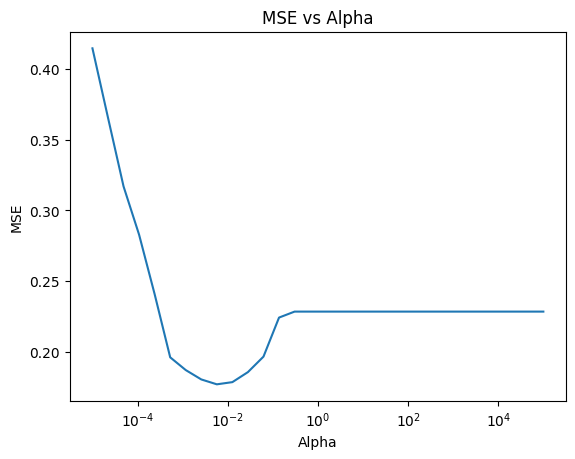

In [25]:
import matplotlib.pyplot as plt

mean_mse = np.mean(lasso.mse_path_, axis=1)

plt.plot(lasso.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.title("MSE vs Alpha")
plt.show()

3.4) The MSE decreases as α increases at first, reaches a minimum around α ≈ 0.0057, and then increases and levels off. This shows that a small amount of regularization gives the best performance.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.908e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.666e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.162e+01, tolerance: 6.518e

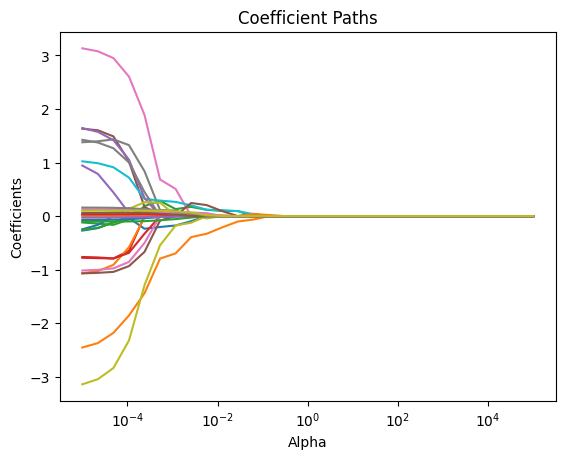

In [26]:
from sklearn.linear_model import Lasso

coefs = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=10000)
    model.fit(X_final, y)
    coefs.append(model.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficients")
plt.title("Coefficient Paths")
plt.show()

3.5) As α increases, all coefficients shrink toward zero. Many coefficients drop quickly and become exactly zero, while a few remain non-zero longer. Eventually, at large α, almost all coefficients are driven to zero. This shows that LASSO performs feature selection by removing less important variables as regularization increases.

In [27]:
lasso_coeffs = pd.Series(lasso.coef_, index=feature_names)

print(lasso_coeffs[lasso_coeffs != 0])

print("\nProportion zero:")
print(np.mean(lasso_coeffs == 0))

ejection_fraction                      -0.329656
serum_creatinine                        0.116875
age^3                                   0.117992
ejection_fraction^3                     0.204822
ejection_fraction^2 serum_creatinine    0.032801
serum_creatinine^3                     -0.043266
anaemia                                 0.014178
diabetes                                0.000607
high_blood_pressure                     0.013608
diabetes high_blood_pressure            0.053968
diabetes smoking                        0.003466
high_blood_pressure smoking             0.017805
dtype: float64

Proportion zero:
0.5862068965517241


In [28]:
comparison = pd.DataFrame({
    "Linear": linreg.coef_,
    "LASSO": lasso.coef_
}, index=feature_names)

print(comparison)

                                          Linear     LASSO
age                                     1.539156 -0.000000
ejection_fraction                      -2.192494 -0.329656
serum_creatinine                       -0.853588  0.116875
age^2                                  -3.678654  0.000000
age ejection_fraction                  -0.600918 -0.000000
age serum_creatinine                    1.841563  0.000000
ejection_fraction^2                     3.430976  0.000000
ejection_fraction serum_creatinine      2.673394  0.000000
serum_creatinine^2                     -2.647041 -0.000000
age^3                                   1.993135  0.117992
age^2 ejection_fraction                 0.908026  0.000000
age^2 serum_creatinine                 -0.697522  0.000000
age ejection_fraction^2                -0.081206  0.000000
age ejection_fraction serum_creatinine -1.577665  0.000000
age serum_creatinine^2                  1.284099 -0.000000
ejection_fraction^3                    -1.250341  0.2048

3.6) The features selected by LASSO are those with non-zero coefficients, including ejection_fraction, serum_creatinine, age³, and several interaction terms.

The proportion of coefficients set to zero is approximately 0.586 (58.6%), meaning over half of the features were removed.

Compared to linear regression:

Many coefficients are reduced to zero
Remaining coefficients are smaller in magnitude
Signs mostly stay the same

The LASSO model makes more sense because it simplifies the model by removing less important features, which helps reduce overfitting and improves the bias-variance trade-off.

# Q4

### 1. Objective Function (Ridge)

$$
\min_{b_0, b_1} \frac{1}{n} \sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)^2 + \alpha b_1^2
$$

---

### 2. Solution for \( b_0 \) and \( b_1 \)

Because the data is mean-centered:

$$
b_0 = 0
$$

$$
b_1 = \frac{\sum \tilde{x}_i \tilde{y}_i}{\sum \tilde{x}_i^2 + \alpha}
$$

---

### 3. Effect of Increasing \( \alpha \)

As \( \alpha \) increases, the denominator increases, so:

- \( b_1 \) decreases  
- The slope shrinks toward 0  

---

### 4. LASSO Challenge

With LASSO (\( +\alpha |b_1| \)):

- The objective is not differentiable at \( b_1 = 0 \)  
- We cannot solve using standard derivatives  

It is optimal to set \( b_1 = 0 \) when:

$$
\left| \sum \tilde{x}_i \tilde{y}_i \right| \le \alpha
$$

---

### Interpretation

- Ridge shrinks coefficients smoothly  
- LASSO can shrink coefficients exactly to zero (feature selection)